In [23]:
#Import
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import flopy
import flopy.modflow as mf
import flopy.mt3d as mt
import flopy.utils as fu

In [24]:
#MODFLOW 2005
modelname = 'example' 
linux_path = '/home/jorge/Documents/github/flopy_documents/linux'
# mf_model = mf.Modflow(modelname = modelname, exe_name='mf2005.exe')
mf_model = mf.Modflow(modelname = modelname, exe_name=f'{linux_path}/mf2005')

In [25]:
#DIS file
Lx = 310
Ly = 310
nrow = 31
ncol = 31
nlay = 1
delr = Lx / ncol
delc = Ly / nrow
top = np.ones((nrow, ncol))
botm = np.zeros((nrow, ncol))
perlen = 27

dis = mf.ModflowDis(mf_model, nlay, nrow, ncol, delr = delr, delc = delc, 
                    top = top, botm = botm, laycbd = 0, itmuni=4, perlen = perlen, 
                    nstp = 1)



# organization of the discretization of the simulation in space and time
# perlen array of floats - stress period lengths
#itmuni =  Time units default is 4
# nstp numger of time stesps in each stress period (default is one)
# laycbd = An array of flags indicating whether or not a layer has a Quasi-3D confining bed below it

In [26]:
# Output Control: Create a flopy output control object
oc = mf.ModflowOc(mf_model)

In [27]:
#BCF file
laycon=0 #confined
tran=1.0 #transmissivity
bcf = flopy.modflow.mfbcf.ModflowBcf(mf_model,laycon=0, tran=1.0)

# tran (float or array of floats (nlay, nrow, ncol), optional) – transmissivity (only read if laycon is 0 or 2) (default is 1.0)
# laycon (int) – Layer type, confined (0), unconfined (1), constant T, variable S (2), variable T, variable S (default is 3)

In [28]:
#BAS file
ibound = np.ones((nlay, nrow, ncol)) #active
ibound[0, 0, :31] = -1 #constant head
ibound[0, 30, :31] = -1
ibound[0, :31, 0] = -1
ibound[0, :31, 30] = -1

strt=15 #starting head

ibound

array([[[-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
         -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
         -1., -1., -1., -1., -1., -1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1.,  1.,  1.,  1., -1.],
        [-1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1

In [29]:
bas = mf.ModflowBas(mf_model, ibound = ibound, strt = strt)


# active 1>0
# constant head 1 < 0
# equal to zero inactive
# ibound dictates which cells participate in flow 
# ibound (array of ints, optional) – The ibound array (the default is 1).
# strt (array of floats, optional) – An array of starting heads (the default is 1.0). 
# ( can i set it to a specific distribution?)

In [30]:
#PCG file
pcg = flopy.modflow.mfpcg.ModflowPcg(mf_model, mxiter=20, iter1=30, hclose=1e-03, rclose=1e-03, relax=1.0)

# mxiter (int) – maximum number of outer iterations. (default is 50)
# iter1 (int) – maximum number of inner iterations. (default is 30)
# hclose (float) – is the head change criterion for convergence. (default is 1e-5).
# rclose (float) – is the residual criterion for convergence. (default is 1e-5)
# relax (float) – is the relaxation parameter used with npcond = 1. (default is 1.0)

In [31]:
#CHD
#[lay, row, col, shead, ehead]

chd=15
chd_data = []
for c in range(30):
    dd = np.array([0, 0, c, chd, chd])
    chd_data.append(dd)
for c in range(31):
    dd = np.array([0, c, 30, chd, chd])
    chd_data.append(dd)
for c in range(30):
    dd = np.array([0, 30, c, chd, chd])
    chd_data.append(dd)
for c in range(1,30):
    dd = np.array([0, c, 0, chd, chd])
    chd_data.append(dd)
stress_period_data = {0:chd_data}

stress_period_data

{0: [array([ 0,  0,  0, 15, 15]),
  array([ 0,  0,  1, 15, 15]),
  array([ 0,  0,  2, 15, 15]),
  array([ 0,  0,  3, 15, 15]),
  array([ 0,  0,  4, 15, 15]),
  array([ 0,  0,  5, 15, 15]),
  array([ 0,  0,  6, 15, 15]),
  array([ 0,  0,  7, 15, 15]),
  array([ 0,  0,  8, 15, 15]),
  array([ 0,  0,  9, 15, 15]),
  array([ 0,  0, 10, 15, 15]),
  array([ 0,  0, 11, 15, 15]),
  array([ 0,  0, 12, 15, 15]),
  array([ 0,  0, 13, 15, 15]),
  array([ 0,  0, 14, 15, 15]),
  array([ 0,  0, 15, 15, 15]),
  array([ 0,  0, 16, 15, 15]),
  array([ 0,  0, 17, 15, 15]),
  array([ 0,  0, 18, 15, 15]),
  array([ 0,  0, 19, 15, 15]),
  array([ 0,  0, 20, 15, 15]),
  array([ 0,  0, 21, 15, 15]),
  array([ 0,  0, 22, 15, 15]),
  array([ 0,  0, 23, 15, 15]),
  array([ 0,  0, 24, 15, 15]),
  array([ 0,  0, 25, 15, 15]),
  array([ 0,  0, 26, 15, 15]),
  array([ 0,  0, 27, 15, 15]),
  array([ 0,  0, 28, 15, 15]),
  array([ 0,  0, 29, 15, 15]),
  array([ 0,  0, 30, 15, 15]),
  array([ 0,  1, 30, 15, 15]),
  arr

chd cell is defined through definition of layer (int), row (int), column (int), shead (float), ehead (float) shead is the head at the start of the stress period, and ehead is the head at the end of the stress period.

for c in range(30): # lay, row, column
    dd = np.array([0, 0, c, chd, chd])
    chd_data.append(dd)       # adds constant head of 15 to the top edge of the model 

 rows increase downward   (zero starts from the top left corner down)    |  ____  ->   columns
 columns increase to the right                                      row  V  |

rows north-south
cols east-west

for layers
0 Top layer            |
1 lower layer          V

adjust duration of time for each stress period in dis

perlen=[30,60,90] so this means kper 0 is 30 days long followed by kper 1 being 60 days and so on.

nper defines how many stress periods are present in the model.
everything uses this as a time reference

if the model consist of 5 nper, it is 5 stress periods long (time)
these portions of time don't have to be equal and their respective duration can be specified with perlen

CHD = head is fixed or specified according to stress period

if you only specify head for less then the totall stress periods in this model, the last specified stress period in CHD will be carried through to the following undefined stress periods.

In [32]:
# constant heads
#What is a stress period, a period a time which simulation property is assumed to be constant



chd = mf.mfchd.ModflowChd(mf_model, stress_period_data=stress_period_data)

#stress_period_data (list of boundaries, recarrays, or dictionary of) – boundaries.

# 05/07/26 to continue again reviewing and documenting functions of this baseline modflow script
# this will be the foundation to my transport simulation.

stress_period_data (list of boundaries, or recarray of boundaries, or) –

dictionary of boundaries Each well is defined through definition of layer (int), row (int), column (int), flux (float). The simplest form is a dictionary with a lists of boundaries for each stress period, where each list of boundaries itself is a list of boundaries. Indices of the dictionary are the numbers of the stress period. This gives the form of:

stress_period_data = {0: [

[lay, row, col, flux], [lay, row, col, flux], [lay, row, col, flux] ],

1: [
[lay, row, col, flux], [lay, row, col, flux], [lay, row, col, flux] ], …

kper:
[ [lay, row, col, flux], [lay, row, col, flux], [lay, row, col, flux] ]

}

In [33]:
#WELL
#[lay, row, col, pumping rate]
# below is descripting  one point source,
# where 100 m3/d of water is being injected into
# the groundwater system at layer 0, 15 units east and 
# 15 units south

# unit length delr height in x 
# unit length delc width in y
pumping_rate = 100 #m3/d
wel_sp1 = [[0, 15, 10, pumping_rate],[0, 15, 18, pumping_rate]]
# wel_sp1 = [[0, 15, 15, pumping_rate]]
stress_period_data = {0: wel_sp1} # dictionary with 1 stress period


wel = flopy.modflow.ModflowWel(mf_model, stress_period_data=stress_period_data)

In [34]:
#LMT Linkage with MT3DMS for multi-species mass transport modeling
lmt = flopy.modflow.ModflowLmt(mf_model, output_file_name='mt3d_link.ftl')

In [35]:
#Write input files
mf_model.write_input()

# run the model
mf_model.run_model()

FloPy is using the following executable to run the model: ../linux/mf2005

                                  MODFLOW-2005     
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUND-WATER FLOW MODEL
                             Version 1.12.00 2/3/2017                        

 Using NAME file: example.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2026/05/08 19:13:43

 Solving:  Stress period:     1    Time step:     1    Ground-Water Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2026/05/08 19:13:43
 Elapsed run time:  0.012 Seconds

  Normal termination of simulation


(True, [])

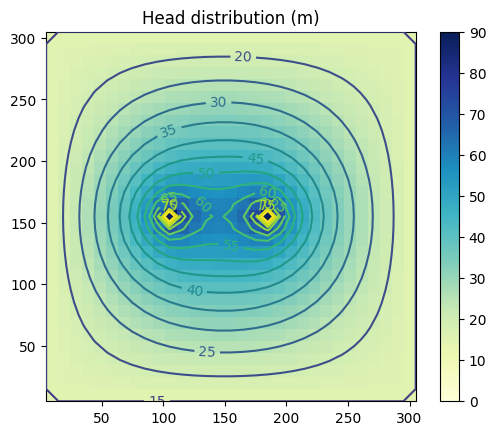

In [36]:
#Plot model results
import matplotlib.pyplot as plt
import flopy.utils.binaryfile as bf

# Create the headfile object
headobj = bf.HeadFile(modelname+'.hds')
head = headobj.get_data(totim=27)
times = headobj.get_times()

# Setup contour parameters
levels = np.arange(0, 90, 5)
extent = (delr/2., Lx - delr/2., delc/2., Ly - delc/2.)

# Make the plots
plt.subplot(1, 1, 1, aspect='equal')
plt.title('Head distribution (m)')
plt.imshow(head[0, :, :], extent=extent, cmap='YlGnBu', vmin=0., vmax=90.)
plt.colorbar()

contours = plt.contour(np.flipud(head[0, :, :]), levels=levels, extent=extent, zorder=10)
plt.clabel(contours, inline=1, fontsize=10, fmt='%d', zorder=11)

plt.show()

In [37]:
#MT3D-USGS
namemt3d='modelnamemt3d' 
# mt_model = mt.Mt3dms(modelname=namemt3d, version='mt3d-usgs', exe_name='MT3D-USGS_64.exe', modflowmodel=mf_model)
mt_model = mt.Mt3dms(modelname=namemt3d, version='mt3d-usgs', exe_name=f'{linux_path}/mt3dms', modflowmodel=mf_model)

sconc (float, array of (nlay, nrow, ncol), or filename) – sconc is the starting concentration for the first species. To specify starting concentrations for other species in a multi-species simulation, include additional keywords, such as sconc2, sconc3, and so forth.

prsity (float or array of floats (nlay, nrow, ncol)) – The effective porosity of the porous medium in a single porosity system, or the mobile porosity in a dual-porosity medium (the immobile porosity is defined through the Chemical Reaction Package. (default is 0.25).

thkmin (float) – The minimum saturated thickness in a cell, expressed as the decimal fraction of its thickness, below which the cell is considered inactive. (default is 0.01).

munit (str) – The name of unit for mass (default is ‘KG’, for ‘kilograms’). Used for identification purposes only.

icbund (int or array of ints (nlay, nrow, ncol)) – The icbund array specifies the boundary condition type for solute species (shared by all species). If icbund = 0, the cell is an inactive concentration cell; If icbund < 0, the cell is a constant-concentration cell; If icbund > 0, the cell is an active concentration cell where the concentration value will be calculated. (default is 1).

In [38]:
#BTN file
icbund = np.ones((nlay, nrow, ncol))
icbund[0, 15, 15] = -1 #constant concentration

btn = flopy.mt3d.Mt3dBtn(mt_model, sconc=0.0, prsity=0.3, thkmin=0.01, munit='g', icbund=icbund)

mixelm (int) – MIXELM is an integer flag for the advection solution option. MIXELM = 0, the standard finite-difference method with upstream or central-in-space weighting, depending on the value of NADVFD; = 1, the forward-tracking method of characteristics (MOC); = 2, the backward-tracking modified method of characteristics (MMOC); = 3, the hybrid method of characteristics (HMOC) with MOC or MMOC automatically and dynamically selected; = -1, the third-order TVD scheme (ULTIMATE).
percel (float) – PERCEL is the Courant number (i.e., the number of cells, or a fraction of a cell) advection will be allowed in any direction in one transport step. For implicit finite-difference or particle-tracking-based schemes, there is no limit on PERCEL, but for accuracy reasons, it is generally not set much greater than one. Note, however, that the PERCEL limit is checked over the entire model grid. Thus, even if PERCEL > 1, advection may not be more than one cell’s length at most model locations. For the explicit finite-difference or the third-order TVD scheme, PERCEL is also a stability constraint which must not exceed one and will be automatically reset to one if a value greater than one is specified.

In [39]:
#ADV file
mixelm = -1 #Third-order TVD scheme (ULTIMATE)
percel = 1 #Courant number PERCEL is also a stability constraint
adv = flopy.mt3d.Mt3dAdv(mt_model, mixelm=mixelm, percel=percel)

In [40]:
#GCG file
mxiter = 1 #Maximum number of outer iterations
iter1 = 200 #Maximum number of inner iterations
isolve = 3 #Preconditioner = Modified Incomplete Cholesky
gcg = flopy.mt3d.Mt3dGcg(mt_model, mxiter=mxiter, iter1=iter1, isolve=isolve)

In [41]:
#DSP file
al = 10 #longitudinal dispersivity
dmcoef = 0 #effective molecular diffusion coefficient
trpt = 0.1 #ratio of the horizontal transverse dispersivity to the longitudinal dispersivity
trpv = 0.01 #ratio of the vertical transverse dispersivity to the longitudinal dispersivity

dsp = mt.Mt3dDsp(mt_model, al=al, dmcoef=dmcoef, trpt=trpt, trpv=trpv)

In [42]:
#SSM file
itype = flopy.mt3d.Mt3dSsm.itype_dict()

#[K,I,J,CSS,iSSType] = layer, row, column, source concentration, type of sink/source: well-constant concentration cell 
ssm_data = {} # M=QC injection well adds contaminant pump wlel removes it
# ssm_data[0] = [(0, 15, 15, 1.0, 2)] # 2 well package (contaminant mass rate = wellflow * concentration)
# ssm_data[0].append((0, 15, 15, 1.0, -1)) # -1 constant concentration
ssm_data[0] = [(0, 15, 10, 1.0, 2)]
ssm_data[0].append((0, 15, 18, 1.0, 2))



ssm = flopy.mt3d.Mt3dSsm(mt_model, stress_period_data=ssm_data)

In [43]:
#Write model input
mt_model.write_input()

#Run the model
mt_model.run_model()

FloPy is using the following executable to run the model: ../linux/mt3dms
 MT3DMS - Modular 3-D Multi-Species Transport Model [Version 5.30]
 Developed at University of Alabama for U.S. Department of Defense

 Using NAME File: modelnamemt3d.nam                                 

 STRESS PERIOD NO.    1

 TIME STEP NO.    1
 FROM TIME =   0.0000     TO    27.000    

 Transport Step:    1   Step Size:  0.5746     Total Elapsed Time:  0.57462    
 Outer Iter.  1  Inner Iter.  1:  Max. DC =  0.7985      [K,I,J]    1   16   19
 Outer Iter.  1  Inner Iter.  2:  Max. DC =  0.1650E-01  [K,I,J]    1   15   20
 Outer Iter.  1  Inner Iter.  3:  Max. DC =  0.1723E-03  [K,I,J]    1   16   11
 Outer Iter.  1  Inner Iter.  4:  Max. DC =  0.4411E-05  [K,I,J]    1   16   20
 Transport Step:    2   Step Size:  0.5746     Total Elapsed Time:   1.1492    
 Outer Iter.  1  Inner Iter.  1:  Max. DC =   2.678      [K,I,J]    1   16   19
 Outer Iter.  1  Inner Iter.  2:  Max. DC =  0.5561E-01  [K,I,J]    1   

(False, [])

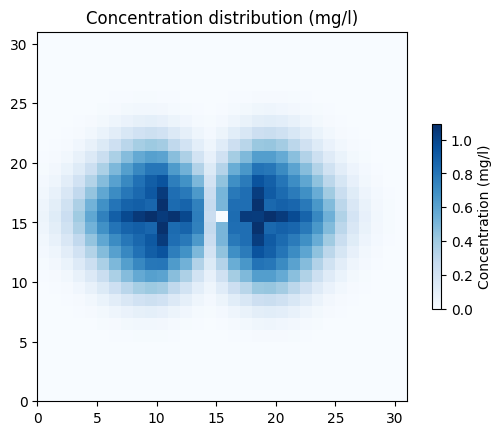

In [44]:
#Plot concentration results
conc = fu.UcnFile('MT3D001.UCN')
conc.plot(totim=times[-1], colorbar='Concentration (mg/l)', cmap='Blues')
plt.title('Concentration distribution (mg/l)')
plt.show()